 <h1 style="font-size: 32px;
       font-weight: 700;">
1.INSTALL AND IMPORT REQUIRED LIBRARIES </h1>
   
   

In [1]:
%pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


 <h1 style="font-size: 32px;
       font-weight: 700;">
                        2.CONNECTING PYTHON TO SQL


In [2]:
import pandas as pd
from sqlalchemy import create_engine
import pymysql

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
engine = create_engine(
    "mysql+pymysql://root:Subscribe@8@localhost:3306/black_friday_project"
)

print("SQL connection engine created successfully!")

SQL connection engine created successfully!


In [4]:
import pymysql

connection = pymysql.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="Subscribe@8",
    database="black_friday_project"
)

print("Python connected to MySQL successfully!")
connection.close()

Python connected to MySQL successfully!


In [5]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="Subscribe@8",
    host="127.0.0.1",
    port=3306,
    database="black_friday_project"
)

engine = create_engine(connection_url)

print("SQLAlchemy engine created successfully!")

SQLAlchemy engine created successfully!


In [6]:
with engine.connect() as conn:
    print("SQLAlchemy connected to MySQL successfully!")

SQLAlchemy connected to MySQL successfully!


 <h1 style="font-size: 32px;
       font-weight: 700;">3.Data Cleaning, Transformations & Enhanced EDA in Python

In [7]:
df = pd.read_sql(
    "SELECT * FROM black_friday_sales LIMIT 10",
    engine
)

df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0,0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6,14,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0,0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14,0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,0,0,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,2,0,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,8,17,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15,0,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,16,0,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,0,0,7871


In [8]:
query = "SELECT * FROM black_friday_sales"

df = pd.read_sql(query, engine)

print("Data loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Data loaded successfully!
Rows: 550068
Columns: 12


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  str  
 7   Marital_Status              550068 non-null  int64
 8   Product_Category_1          550068 non-null  int64
 9   Product_Category_2          550068 non-null  int64
 10  Product_Category_3          550068 non-null  int64
 11  Purchase                    550068 non-null  int64
dtypes: int64(7), str(5)
memory usage: 59.3 MB


In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0,0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6,14,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0,0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14,0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,0,0,7969


In [10]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [26]:
df.shape

(550068, 12)

In [13]:
df.dtypes

User_ID                       int64
Product_ID                      str
Gender                          str
Age                             str
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years      str
Marital_Status                int64
Product_Category_1            int64
Product_Category_2            int64
Product_Category_3            int64
Purchase                      int64
dtype: object

In [11]:
df.describe(include="all")

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068,550068.000000,550068.000000,550068.000000,550068.000000,550068.000000
unique,NaN,3631,2,7,NaN,3,5,NaN,NaN,NaN,NaN,NaN
top,NaN,P00265242,M,26-35,NaN,B,1,NaN,NaN,NaN,NaN,NaN
freq,NaN,1880,414259,219587,NaN,231173,193821,NaN,NaN,NaN,NaN,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,NaN,0.409653,5.404270,6.735436,3.841941,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,NaN,0.491770,3.936211,6.215492,6.250712,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,1.000000,0.000000,0.000000,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,NaN,0.000000,1.000000,0.000000,0.000000,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,NaN,0.000000,5.000000,5.000000,0.000000,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,NaN,1.000000,8.000000,14.000000,8.000000,12054.000000


In [12]:
df["Gender"].value_counts()

Gender
M    414259
F    135809
Name: count, dtype: int64

| Gender    | Transactions |      Share |
| --------- | -----------: | ---------: |
| M         |      414,259 | **75.31%** |
| F         |      135,809 | **24.69%** |
| **Total** |  **550,068** |   **100%** |


📌 Insight
Male customers account for roughly 75% of transactions.
Female customers account for roughly 25%.
The dataset therefore shows a strong male skew in purchasing activ

In [13]:
df["Age"].value_counts().sort_index()

Age
0-17      15102
18-25     99660
26-35    219587
36-45    110013
46-50     45701
51-55     38501
55+       21504
Name: count, dtype: int64

📌 Insight

Customers aged 26–35 account for the largest share of transactions (~40%), making them the dominant age group in the Black Friday dataset. The 36–45 group follows at ~20%, while 18–25 contributes ~18%.

This is a useful business insight for your project because the 26–35 segment appears to be the strongest customer group by transaction volume.

In [14]:
df["Occupation"].value_counts().sort_index()

Occupation
0     69638
1     47426
2     26588
3     17650
4     72308
5     12177
6     20355
7     59133
8      1546
9      6291
10    12930
11    11586
12    31179
13     7728
14    27309
15    12165
16    25371
17    40043
18     6622
19     8461
20    33562
Name: count, dtype: int64

In [36]:
df["City_Category"].value_counts().sort_index()

City_Category
A    147720
B    231173
C    171175
Name: count, dtype: int64

In [37]:
df["Stay_In_Current_City_Years"].value_counts().sort_index()

Stay_In_Current_City_Years
0      74398
1     193821
2     101838
3      95285
4+     84726
Name: count, dtype: int64

In [38]:
df["Marital_Status"].value_counts().sort_index()

Marital_Status
0    324731
1    225337
Name: count, dtype: int64

In [15]:
df["Product_Category_1"].value_counts().sort_index()

Product_Category_1
1     140378
2      23864
3      20213
4      11753
5     150933
6      20466
7       3721
8     113925
9        410
10      5125
11     24287
12      3947
13      5549
14      1523
15      6290
16      9828
17       578
18      3125
19      1603
20      2550
Name: count, dtype: int64

In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Rows: 550068
Columns: 12

Column names:
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']


In [15]:
df["Product_Category_2"].value_counts(dropna=False).sort_index()

Product_Category_2
0     173638
2      49217
3       2884
4      25677
5      26235
6      16466
7        626
8      64088
9       5693
10      3043
11     14134
12      5528
13     10531
14     55108
15     37855
16     43255
17     13320
18      2770
Name: count, dtype: int64

In [16]:
df["Product_Category_3"].value_counts(dropna=False).sort_index()

Product_Category_3
0     383247
3        613
4       1875
5      16658
6       4890
8      12562
9      11579
10      1726
11      1805
12      9246
13      5459
14     18428
15     28013
16     32636
17     16702
18      4629
Name: count, dtype: int64

In [17]:
df["Purchase"].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

In [19]:
df["Purchase"].isnull().sum()

np.int64(0)

In [20]:
df["Purchase"].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

In [21]:
df["Purchase"].isnull().sum()

np.int64(0)

In [22]:
df.duplicated().sum()

np.int64(0)

In [16]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Product_ID:
<ArrowStringArray>
['P00069042', 'P00248942', 'P00087842', 'P00085442', 'P00285442', 'P00193542',
 'P00184942', 'P00346142',  'P0097242', 'P00274942',
 ...
 'P00295642', 'P00091742', 'P00350742', 'P00060842', 'P00057842', 'P00375436',
 'P00372445', 'P00370293', 'P00371644', 'P00370853']
Length: 3631, dtype: str

Gender:
<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

Age:
<ArrowStringArray>
['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']
Length: 7, dtype: str

City_Category:
<ArrowStringArray>
['A', 'C', 'B']
Length: 3, dtype: str

Stay_In_Current_City_Years:
<ArrowStringArray>
['2', '4+', '3', '1', '0']
Length: 5, dtype: str


C:\Users\santo\AppData\Local\Temp\ipykernel_16920\578808310.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [17]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [69]:
# Treat 0 as Unknown for Product Category 2 and 3
df_final["Product_Category_2"] = df_final["Product_Category_2"].replace(0, "Unknown")
df_final["Product_Category_3"] = df_final["Product_Category_3"].replace(0, "Unknown")

In [25]:
df.dtypes

User_ID                       int64
Product_ID                      str
Gender                          str
Age                             str
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years      str
Marital_Status                int64
Product_Category_1            int64
Product_Category_2            int64
Product_Category_3            int64
Purchase                      int64
dtype: object

In [26]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,6.735436,3.841941,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,6.215492,6.250712,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,0.000000,0.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,0.000000,0.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,5.000000,0.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,14.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [28]:
df["Gender"].value_counts()

Gender
M    414259
F    135809
Name: count, dtype: int64

In [29]:
df["Age"].value_counts().sort_index()

Age
0-17      15102
18-25     99660
26-35    219587
36-45    110013
46-50     45701
51-55     38501
55+       21504
Name: count, dtype: int64

In [30]:
df["Occupation"].value_counts().sort_index()

Occupation
0     69638
1     47426
2     26588
3     17650
4     72308
5     12177
6     20355
7     59133
8      1546
9      6291
10    12930
11    11586
12    31179
13     7728
14    27309
15    12165
16    25371
17    40043
18     6622
19     8461
20    33562
Name: count, dtype: int64

In [32]:
df["City_Category"].value_counts().sort_index()

City_Category
A    147720
B    231173
C    171175
Name: count, dtype: int64

In [33]:
df["Stay_In_Current_City_Years"].value_counts().sort_index()

Stay_In_Current_City_Years
0      74398
1     193821
2     101838
3      95285
4+     84726
Name: count, dtype: int64

In [35]:
df["Marital_Status"].value_counts().sort_index()

Marital_Status
0    324731
1    225337
Name: count, dtype: int64

In [36]:
df["Product_Category_1"].value_counts().sort_index()

Product_Category_1
1     140378
2      23864
3      20213
4      11753
5     150933
6      20466
7       3721
8     113925
9        410
10      5125
11     24287
12      3947
13      5549
14      1523
15      6290
16      9828
17       578
18      3125
19      1603
20      2550
Name: count, dtype: int64

In [38]:
df["Product_Category_2"].value_counts(dropna=False).sort_index()

Product_Category_2
0     173638
2      49217
3       2884
4      25677
5      26235
6      16466
7        626
8      64088
9       5693
10      3043
11     14134
12      5528
13     10531
14     55108
15     37855
16     43255
17     13320
18      2770
Name: count, dtype: int64

In [39]:
df["Product_Category_3"].value_counts(dropna=False).sort_index()

Product_Category_3
0     383247
3        613
4       1875
5      16658
6       4890
8      12562
9      11579
10      1726
11      1805
12      9246
13      5459
14     18428
15     28013
16     32636
17     16702
18      4629
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  str  
 7   Marital_Status              550068 non-null  int64
 8   Product_Category_1          550068 non-null  int64
 9   Product_Category_2          550068 non-null  int64
 10  Product_Category_3          550068 non-null  int64
 11  Purchase                    550068 non-null  int64
dtypes: int64(7), str(5)
memory usage: 59.3 MB


In [18]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0,0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6,14,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0,0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14,0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,0,0,7969


In [17]:
df.groupby("Gender")["Purchase"].agg(["count", "mean", "sum"]).round(2)

,count,mean,sum
Gender,,,
F,135809,8734.57,1186232642
M,414259,9437.53,3909580100


In [18]:
df.groupby("Age")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
Age,,,
0-17,15102,8933.46,134913183
18-25,99660,9169.66,913848675
26-35,219587,9252.69,2031770578
36-45,110013,9331.35,1026569884
46-50,45701,9208.63,420843403
51-55,38501,9534.81,367099644
55+,21504,9336.28,200767375


In [19]:
df.groupby("Occupation")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
Occupation,,,
0,69638,9124.43,635406958
1,47426,8953.19,424614144
2,26588,8952.48,238028583
3,17650,9178.59,162002168
4,72308,9213.98,666244484
5,12177,9333.15,113649759
6,20355,9256.54,188416784
7,59133,9425.73,557371587
8,1546,9532.59,14737388


In [20]:
df.groupby("City_Category")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
City_Category,,,
A,147720,8911.94,1316471661
B,231173,9151.30,2115533605
C,171175,9719.92,1663807476


In [21]:
df.groupby("Stay_In_Current_City_Years")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
Stay_In_Current_City_Years,,,
0,74398,9180.08,682979229
1,193821,9250.15,1792872533
2,101838,9320.43,949173931
3,95285,9286.90,884902659
4+,84726,9275.60,785884390


In [19]:
df.groupby("Marital_Status")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
Marital_Status,,,
0,324731,9265.91,3008927447
1,225337,9261.17,2086885295


In [23]:
df.groupby("Product_Category_2")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
Product_Category_2,,,
0,173638,7518.70,1305531230
2,49217,13619.36,670303864
3,2884,11235.36,32402777
4,25677,10215.19,262295485
5,26235,9027.82,236844899
6,16466,11503.55,189417477
7,626,6884.68,4309812
8,64088,10273.26,658392656
9,5693,7277.01,41428000


In [24]:
df.groupby("Product_Category_3")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

,count,mean,sum
Product_Category_3,,,
0,383247,8221.84,3150994343
3,613,13939.70,8545034
4,1875,9794.39,18364475
5,16658,12117.79,201858094
6,4890,13194.31,64520181
8,12562,13024.92,163619031
9,11579,10431.70,120788622
10,1726,13505.81,23311034
11,1805,12091.44,21825045


In [25]:
df.groupby(["Gender", "Age"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Gender Age                               
F      0-17     5083  8338.77    42385978
       18-25   24628  8343.18   205475842
       26-35   50752  8728.25   442976233
       36-45   27170  8959.84   243438963
       46-50   13199  8842.10   116706864
       51-55    9894  9042.45    89465997
       55+      5083  9007.04    45782765
M      0-17    10019  9235.17    92527205
       18-25   75032  9440.94   708372833
       26-35  168835  9410.34  1588794345
       36-45   82843  9453.19   783130921
       46-50   32502  9357.47   304136539
       51-55   28607  9705.09   277633647
       55+     16421  9438.20   154984610

In [20]:
df.groupby(["Gender", "City_Category"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Gender City_Category                             
F      A               35704  8579.71   306329915
       B               57796  8540.68   493617008
       C               42309  9130.11   386285719
M      A              112016  9017.83  1010141746
       B              173377  9354.85  1621916597
       C              128866  9913.57  1277521757

In [27]:
df.groupby(["Gender", "Stay_In_Current_City_Years"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Gender Stay_In_Current_City_Years                             
F      0                            17063  8606.04   146844869
       1                            51298  8775.05   450142630
       2                            24332  8740.52   212674244
       3                            24520  8695.24   213207201
       4+                           18596  8784.88   163363698
M      0                            57335  9350.91   536134360
       1                           142523  9421.15  1342729903
       2                            77506  9502.49   736499687
       3                            70765  9491.92   671695458
       4+                           66130  9413.59   622520692

In [28]:
df.groupby(["Gender", "Marital_Status"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Gender Marital_Status                             
F      0                78821  8679.85   684154127
       1                56988  8810.25   502078515
M      0               245910  9453.76  2324773320
       1               168349  9413.82  1584806780

In [29]:
df.groupby(["Gender", "Product_Category_1"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean         sum
Gender Product_Category_1                              
F      1                    24831  13597.16   337631145
       2                     5658  11407.50    64543617
       3                     6006  10262.66    61637516
       4                     3639   2454.85     8933206
       5                    41961   6307.24   264658078
       6                     4559  15596.43    71104116
       7                      943  16394.85    15460347
       8                    33558   7499.92   251682476
       9                       70  15724.31     1100702
       10                    1162  19692.08    22882193
       11                    4739   4676.37    22161326
       12                    1532   1422.91     2179897
       13                    1462    733.85     1072884
       14                     623  13747.36     8564607
       15                    1046  14695.33    15371312
       16                    2402  14681.49    35264942
       17                      62   9846.40      610477
       18                     382   2848.61     1088168
       19                     451     37.68       16992
       20                     723    371.56      268641
M      1                   115547  13608.16  1572382609
       2                    18206  11203.59   203972569
       3                    14207  10026.55   142447197
       4                     8114   2273.51    18447282
       5                   108972   6214.23   677177151
       6                    15907  15907.85   253046186
       7                     2778  16355.79    45436384
       8                    80367   7498.55   602636323
       9                      340  15498.89     5269622
       10                    3963  19670.73    77955108
       11                   19548   4687.43    91629789
       12                    2415   1305.15     3151947
       13                    4087    718.31     2935717
       14                     900  12722.32    11450089
       15                    5244  14797.43    77597730
       16                    7426  14793.38   109855670
       17                     516  10209.73     5268222
       18                    2743   2990.17     8202033
       19                    1152     36.79       42386
       20                    1827    370.05      676086

In [30]:
df.groupby(["Gender", "Product_Category_2"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean        sum
Gender Product_Category_2                             
F      0                    44279   7422.20  328647518
       2                     9199  13753.21  126515808
       3                      617  11085.96    6840035
       4                     7619  10518.94   80143780
       5                     6155   8049.64   49545524
       6                     3291  10734.59   35327529
       7                      137   6885.26     943280
       8                    16529   9461.31  156385934
       9                     1497   7195.85   10772193
       10                     736  15454.71   11374668
       11                    2754   8476.26   23343608
       12                    1744   7069.47   12329161
       13                    2669   9262.87   24722605
       14                   19693   6964.91  137160052
       15                    6432   9903.27   63697857
       16                    9496   9749.12   92577654
       17                    2484   8921.39   22160745
       18                     478   7834.08    3744691
M      0                   129359   7551.73  976883712
       2                    40018  13588.59  543788056
       3                     2267  11276.02   25562742
       4                    18058  10087.04  182151705
       5                    20080   9327.66  187299375
       6                    13175  11695.63  154089948
       7                      489   6884.52    3366532
       8                    47559  10555.45  502006722
       9                     4196   7305.96   30655807
       10                    2307  15710.63   36244416
       11                   11380   9052.95  103022557
       12                    3784   6932.15   26231251
       13                    7862   9826.10   77252779
       14                   35415   7183.31  254396887
       15                   31423  10449.97  328369319
       16                   33759  10449.42  352762068
       17                   10836   9536.24  103334655
       18                    2292   9669.10   22161569

In [31]:
df.groupby(["Gender", "Product_Category_3"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean         sum
Gender Product_Category_3                              
F      0                    98215   7834.99   769513536
       3                       95  13136.29     1247948
       4                      433  10426.00     4514456
       5                     4297  12147.26    52196770
       6                      828  13040.39    10797446
       8                     2941  12173.71    35802892
       9                     2676  10039.56    26865866
       10                     414  13423.69     5557407
       11                     334  11454.24     3825715
       12                    2722   8900.14    24226179
       13                    1229  13131.15    16138188
       14                    5623   9503.91    53440501
       15                    4610  12111.22    55832744
       16                    6774  11301.99    76559647
       17                    3738  10670.93    39887923
       18                     880  11165.25     9825424
M      0                   285032   8355.13  2381480807
       3                      518  14087.04     7297086
       4                     1442   9604.73    13850019
       5                    12361  12107.54   149661324
       6                     4062  13225.69    53722735
       8                     9621  13285.12   127816139
       9                     8903  10549.56    93922756
       10                    1312  13531.73    17753627
       11                    1471  12236.12    17999330
       12                    6524   8638.48    56357452
       13                    4230  13200.80    55839375
       14                   12805  10293.53   131808711
       15                   23403  12384.31   289830025
       16                   25862  12159.98   314481336
       17                   12964  12086.83   156693665
       18                    3749  10953.78    41065713

In [32]:
df.groupby(["Marital_Status", "Age"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Marital_Status Age                               
0              0-17    15102  8933.46   134913183
               18-25   78544  9216.75   723920602
               26-35  133296  9252.57  1233330102
               36-45   66377  9402.52   624110760
               46-50   12690  8956.53   113658360
               51-55   10839  9575.83   103792394
               55+      7883  9539.77    75202046
1              18-25   21116  8994.51   189928073
               26-35   86291  9252.88   798440476
               36-45   43636  9223.10   402459124
               46-50   33011  9305.54   307185043
               51-55   27662  9518.74   263307250
               55+     13621  9218.51   125565329

In [33]:
df.groupby(["Marital_Status", "City_Category"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Marital_Status City_Category                             
0              A               91173  8975.80   818350626
               B              136721  9147.14  1250605488
               C               96837  9706.74   939971333
1              A               56547  8808.97   498121035
               B               94452  9157.33   864928117
               C               74338  9737.09   723836143

In [34]:
df.groupby(["Marital_Status", "Stay_In_Current_City_Years"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean         sum
Marital_Status Stay_In_Current_City_Years                             
0              0                            44908  9199.70   413140099
               1                           110696  9241.86  1023036909
               2                            60800  9307.26   565881440
               3                            57647  9362.87   539741219
               4+                           50680  9217.20   467127780
1              0                            29490  9150.19   269839130
               1                            83125  9261.18   769835624
               2                            41038  9339.94   383292491
               3                            37638  9170.56   345161440
               4+                           34046  9362.53   318756610

In [21]:
df.groupby(["Marital_Status", "Product_Category_1"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean         sum
Marital_Status Product_Category_1                             
0              1                   84375  13589.27  1146594992
               2                   14138  11176.20   158009058
               3                   12359  10026.93   123922879
               4                    7177   2308.02    16564669
               5                   89656   6223.85   558005574
               6                   12139  15864.71   192581656
               7                    2040  16413.88    33484311
               8                   65411   7483.96   489533223
               9                     247  15880.94     3922592
               10                   2778  19665.58    54630983
               11                  14668   4725.17    69308836
               12                   2034   1349.73     2745347
               13                   3162    725.03     2292541
               14                    846  13084.71    11069661
               15                   3623  14766.29    53498269
               16                   5713  14745.53    84241239
               17                    298  10132.42     3019460
               18                   1641   3000.17     4923284
               19                    946     37.27       35260
               20                   1480    367.31      543613
1              1                   56003  13631.75   763418762
               2                    9726  11362.03   110507128
               3                    7854  10206.50    80161834
               4                    4576   2363.60    10815819
               5                   61277   6263.85   383829655
               6                    8327  15800.25   131568646
               7                    1681  16307.21    27412420
               8                   48514   7519.18   364785576
               9                     163  15016.76     2447732
               10                   2347  19687.40    46206318
               11                   9619   4624.42    44482279
               12                   1913   1352.06     2586497
               13                   2387    718.92     1716060
               14                    677  13212.75     8945035
               15                   2667  14799.69    39470773
               16                   4115  14794.50    60879373
               17                    280  10211.57     2859239
               18                   1484   2942.67     4366917
               19                    657     36.71       24118
               20                   1070    374.87      401114

In [36]:
df.groupby(["Marital_Status", "Product_Category_2"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean        sum
Marital_Status Product_Category_2                             
0              0                   101248   7482.09  757546910
               2                    29872  13592.03  406021197
               3                     1801  11141.95   20066644
               4                    15812  10140.91  160348122
               5                    15903   8949.27  142320302
               6                     9804  11473.78  112488934
               7                      369   6946.54    2563272
               8                    37354  10309.09  385085635
               9                     3423   7256.17   24837856
               10                    1647  15659.16   25790630
               11                    8602   8889.69   76469074
               12                    3120   6945.95   21671363
               13                    5976   9529.18   56946407
               14                   32391   7097.41  229892285
               15                   22416  10429.30  233783284
               16                   25914  10330.40  267701988
               17                    7579   9421.15   71402869
               18                    1500   9327.12   13990675
1              0                    72390   7569.89  547984320
               2                    19345  13661.55  264282667
               3                     1083  11390.70   12336133
               4                     9865  10334.25  101947363
               5                    10332   9148.72   94524597
               6                     6662  11547.36   76928543
               7                      257   6795.88    1746540
               8                    26734  10223.20  273307021
               9                     2270   7308.43   16590144
               10                    1396  15636.43   21828454
               11                    5532   9019.72   49897091
               12                    2408   7013.72   16889049
               13                    4555   9885.62   45028977
               14                   22717   7116.46  161664654
               15                   15439  10252.21  158283892
               16                   17341  10243.80  177637734
               17                    5741   9422.14   54092531
               18                    1270   9382.35   11915585

In [37]:
df.groupby(["Marital_Status", "Product_Category_3"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean         sum
Marital_Status Product_Category_3                              
0              0                   225112   8215.79  1849471961
               3                      387  14058.18     5440517
               4                     1210   9727.43    11770195
               5                    10256  12056.36   123650070
               6                     3055  13248.57    40474391
               8                     7368  13042.50    96097142
               9                     7156  10434.63    74670191
               10                     957  13368.30    12793459
               11                    1106  12148.66    13436423
               12                    5590   8633.22    48259703
               13                    3261  13137.76    42842237
               14                   10724  10103.80   108353187
               15                   16663  12313.22   205175192
               16                   19589  11959.87   234281925
               17                    9594  11736.50   112599942
               18                    2703  10954.83    29610912
1              0                   158135   8230.45  1301522382
               3                      226  13736.80     3104517
               4                      665   9916.21     6594280
               5                     6402  12216.19    78208024
               6                     1835  13103.97    24045790
               8                     5194  12999.98    67521889
               9                     4423  10426.96    46118431
               10                     769  13676.95    10517575
               11                     699  12000.89     8388622
               12                    3656   8841.34    32323928
               13                    2198  13255.38    29135326
               14                    7704   9981.31    76896025
               15                   11350  12377.76   140487577
               16                   13047  12014.95   156759058
               17                    7108  11815.09    83981646
               18                    1926  11048.92    21280225

In [38]:
df.groupby(["Occupation", "Age"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean        sum
Occupation Age                              
0          0-17    2134   9305.18   19857261
           18-25   9095   9167.15   83375228
           26-35  34204   9113.09  311704132
           36-45  13393   9356.15  125306946
           46-50   4488   8391.75   37662191
...                 ...       ...        ...
20         26-35  13994   8763.91  122642203
           36-45   7508   8992.29   67514106
           46-50   2699   8347.96   22531153
           51-55   3115   9340.66   29096169
           55+      801  10879.62    8714577

[134 rows x 3 columns]

In [40]:
df.groupby(["Occupation", "City_Category"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean        sum
Occupation City_Category                           
0          A              18858  8860.17  167085036
           B              29850  9042.80  269927510
           C              20930  9478.95  198394412
1          A              12809  8738.25  111928230
           B              19756  8763.50  173131708
...                         ...      ...        ...
19         B               3400  8867.88   30150793
           C               2825  8809.12   24885754
20         A              12743  8345.23  106343272
           B              14400  9021.22  129905603
           C               6419  9397.35   60321567

[63 rows x 3 columns]

In [41]:
df.groupby(["Occupation", "Stay_In_Current_City_Years"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count     mean        sum
Occupation Stay_In_Current_City_Years                           
0          0                           10622  9103.39   96696212
           1                           24690  9230.27  227895360
           2                           12551  9120.38  114469916
           3                           10776  9159.98   98707976
           4+                          10999  8876.94   97637494
...                                      ...      ...        ...
20         0                            3676  9417.37   34618243
           1                           12912  8829.19  114002561
           2                            5394  8938.52   48214394
           3                            6485  8444.51   54762625
           4+                           5095  8826.81   44972619

[104 rows x 3 columns]

In [22]:
df.groupby(["Occupation", "Marital_Status"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)


count     mean        sum
Occupation Marital_Status                           
0          0               40489  9158.67  370825372
           1               29149  9076.87  264581586
1          0               24724  8962.76  221595254
           1               22702  8942.78  203018890
2          0               14306  9137.13  130715770
           1               12282  8737.41  107312813
3          0               10364  9261.77   95988995
           1                7286  9060.28   66013173
4          0               52776  9238.96  487595558
           1               19532  9146.47  178648926
5          0                7608  9391.89   71453497
           1                4569  9235.34   42196262
6          0               11190  9276.74  103806681
           1                9165  9231.87   84610103
7          0               33403  9380.21  313327193
           1               25730  9484.82  244044394
8          0                 691  9200.37    6357455
           1                 855  9801.09    8379933
9          0                3038  8451.75   25676420
           1                3253  8811.44   28663626
10         0               12177  8933.20  108779592
           1                 753  9382.30    7064873
11         0                7140  9071.36   64769488
           1                4446  9442.67   41982130
12         0               16680  9833.52  164023062
           1               14499  9754.22  141426384
13         0                3630  9187.08   33349086
           1                4098  9412.00   38570395
14         0               16062  9415.43  151230666
           1               11247  9622.48  108224026
15         0                6650  9795.83   65142251
           1                5515  9758.47   53817960
16         0               13368  9502.67  127031633
           1               12003  9273.96  111315322
17         0               22732  9783.67  222402436
           1               17311  9871.12  170879017
18         0                3615  9085.11   32842665
           1                3007  9271.30   27878796
19         0                6926  8689.99   60186842
           1                1535  8803.76   13513775
20         0               17162  8846.73  151827531
           1               16400  8825.79  144742911

In [43]:
df.groupby(["Occupation", "Product_Category_1"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean        sum
Occupation Product_Category_1                            
0          1                   17643  13335.64  235280682
           2                    2971  11256.07   33441771
           3                    2635  10105.05   26626795
           4                    1481   2390.56    3540426
           5                   18985   6196.33  117637404
...                              ...       ...        ...
20         16                    584  14159.15    8268945
           17                     46   9949.89     457695
           18                    180   3044.13     547943
           19                     65     39.63       2576
           20                    121    379.26      45890

[419 rows x 3 columns]

In [44]:
df.groupby(["Occupation", "Product_Category_2"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean        sum
Occupation Product_Category_2                            
0          0                   22279   7464.25  166296088
           2                    6099  13391.52   81674869
           3                     352  11203.49    3943629
           4                    3366  10239.41   34465867
           5                    3365   9043.48   30431317
...                              ...       ...        ...
20         14                   3365   6688.54   22506947
           15                   2071   9967.90   20643529
           16                   2357   9660.17   22769012
           17                    829   9448.86    7833104
           18                    159   9266.76    1473415

[378 rows x 3 columns]

In [26]:
df.groupby(["Occupation", "Product_Category_3"])["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

count      mean        sum
Occupation Product_Category_3                            
0          0                   48667   8110.75  394726060
           3                      77  13341.97    1027332
           4                     260   9989.61    2597299
           5                    2126  12047.24   25612438
           6                     673  13047.00    8780630
...                              ...       ...        ...
20         14                   1171   9590.28   11230221
           15                   1384  11873.90   16433481
           16                   1769  11724.14   20739999
           17                    908  10850.17    9851950
           18                    256  10470.39    2680420

[336 rows x 3 columns]

In [25]:
customer_purchase = df.groupby("User_ID")["Purchase"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

customer_purchase.head(10)

,count,mean,sum
User_ID,,,
1004277,979,10762.930541,10536909
1001680,1026,8479.138402,8699596
1002909,718,10553.977716,7577756
1001941,898,7591.863029,6817493
1000424,694,9472.059078,6573609
1004448,575,11419.556522,6566245
1005831,727,8957.954608,6512433
1001015,740,8799.072973,6511314
1003391,698,9279.598854,6477160


In [27]:
customer_purchase["sum"].describe()

count    5.891000e+03
mean     8.650166e+05
std      9.436445e+05
min      4.668100e+04
25%      2.376780e+05
50%      5.212130e+05
75%      1.119250e+06
max      1.053691e+07
Name: sum, dtype: float64

In [28]:
hvc_threshold = customer_purchase["sum"].quantile(0.90)

hvc_customers = customer_purchase[
    customer_purchase["sum"] >= hvc_threshold
]

print("High-value customer threshold:", round(hvc_threshold, 2))
print("Number of high-value customers:", len(hvc_customers))
print("Percentage of customers:", round(len(hvc_customers) / len(customer_purchase) * 100, 2))

High-value customer threshold: 2069404.0
Number of high-value customers: 590
Percentage of customers: 10.02


In [34]:
hvc_sales = hvc_customers["sum"].sum()
total_sales = df["Purchase"].sum()

print("High-value customer sales:", hvc_sales)
print("Total sales:", total_sales)
print("HVC contribution to total sales (%):",
      round(hvc_sales / total_sales * 100, 2))

High-value customer sales: 1840603143
Total sales: 5095812742
HVC contribution to total sales (%): 36.12


In [31]:
repeat_customers = customer_purchase[
    customer_purchase["count"] > 1
]

print("Total customers:", len(customer_purchase))
print("Repeat customers:", len(repeat_customers))
print("Repeat customer percentage:",
      round(len(repeat_customers) / len(customer_purchase) * 100, 2))

Total customers: 5891
Repeat customers: 5891
Repeat customer percentage: 100.0


In [35]:
repeat_sales = repeat_customers["sum"].sum()

print("Repeat customer sales:", repeat_sales)
print("Total sales:", total_sales)
print("Repeat customer contribution (%):",
      round(repeat_sales / total_sales * 100, 2))

Repeat customer sales: 5095812742
Total sales: 5095812742
Repeat customer contribution (%): 100.0


In [36]:
customer_type = pd.DataFrame({
    "Customer_Type": ["One-time", "Repeat"],
    "Customers": [
        len(customer_purchase[customer_purchase["count"] == 1]),
        len(repeat_customers)
    ],
    "Avg_Total_Purchase": [
        customer_purchase[customer_purchase["count"] == 1]["sum"].mean(),
        repeat_customers["sum"].mean()
    ]
})

customer_type.round(2)

,Customer_Type,Customers,Avg_Total_Purchase
0,One-time,0,NaN
1,Repeat,5891,865016.59


In [37]:
customer_frequency = pd.cut(
    customer_purchase["count"],
    bins=[0, 1, 5, float("inf")],
    labels=["One-time", "Occasional", "Frequent"]
)

customer_frequency.value_counts().sort_index()

count
One-time         0
Occasional       0
Frequent      5891
Name: count, dtype: int64

In [54]:
segment_sales = customer_purchase.groupby(customer_frequency, observed=True)["sum"].agg(
    ["count", "sum", "mean"]
)

segment_sales.columns = [
    "Customers",
    "Total_Sales",
    "Avg_Customer_Sales"
]

segment_sales.round(2)

,Customers,Total_Sales,Avg_Customer_Sales
count,,,
Frequent,5891,5095812742,865016.59


In [38]:
top_products = df.groupby("Product_ID")["Purchase"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

top_products.head(10)

,count,mean,sum
Product_ID,,,
P00025442,1615,17334.468111,27995166
P00110742,1612,16577.114764,26722309
P00255842,1383,18198.816341,25168963
P00059442,1406,17310.343528,24338343
P00184942,1440,16899.227083,24334887
P00112142,1562,15503.204866,24216006
P00110942,1360,17382.032353,23639564
P00237542,1394,16804.573888,23425576
P00057642,1470,15716.176871,23102780


In [56]:
top_products_by_count = top_products.sort_values(
    "count", ascending=False
)

top_products_by_count.head(10)

,count,mean,sum
Product_ID,,,
P00265242,1880,7534.848404,14165515
P00025442,1615,17334.468111,27995166
P00110742,1612,16577.114764,26722309
P00112142,1562,15503.204866,24216006
P00057642,1470,15716.176871,23102780
P00184942,1440,16899.227083,24334887
P00046742,1438,14709.931850,21152882
P00058042,1422,8615.073136,12250634
P00059442,1406,17310.343528,24338343


In [39]:
category1_performance = df.groupby("Product_Category_1")["Purchase"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

category1_performance.round(2)

,count,mean,sum
Product_Category_1,,,
1,140378,13606.22,1910013754
5,150933,6240.09,941835229
8,113925,7498.96,854318799
6,20466,15838.48,324150302
2,23864,11251.94,268516186
3,20213,10096.71,204084713
16,9828,14766.04,145120612
11,24287,4685.27,113791115
10,5125,19675.57,100837301


In [58]:
category2_performance = df.groupby("Product_Category_2")["Purchase"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

category2_performance.round(2)

,count,mean,sum
Product_Category_2,,,
0,173638,7518.70,1305531230
2,49217,13619.36,670303864
8,64088,10273.26,658392656
16,43255,10295.68,445339722
15,37855,10357.08,392067176
14,55108,7105.26,391556939
4,25677,10215.19,262295485
5,26235,9027.82,236844899
6,16466,11503.55,189417477


In [40]:
category2_performance = df.groupby("Product_Category_3")["Purchase"].agg(
    ["count", "mean", "sum"]
).sort_values("sum", ascending=False)

category2_performance.round(2)

,count,mean,sum
Product_Category_3,,,
0,383247,8221.84,3150994343
16,32636,11981.89,391040983
15,28013,12339.37,345662769
5,16658,12117.79,201858094
17,16702,11769.94,196581588
14,18428,10052.59,185249212
8,12562,13024.92,163619031
9,11579,10431.70,120788622
12,9246,8715.51,80583631


In [60]:
city_category_product = df.groupby(
    ["City_Category", "Product_Category_1"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_category_product

count      mean        sum
City_Category Product_Category_1                            
A             1                   35081  13047.18  457708014
              2                    6141  10903.55   66958730
              3                    4943  10032.38   49590060
              4                    3050   2269.74    6922707
              5                   42211   6117.84  258240117
              6                    5507  15519.77   85467361
              7                    1226  16239.24   19909313
              8                   32179   7328.07  235809873
              9                     110  14821.15    1630326
              10                   1333  19530.49   26034148
              11                   6601   4577.94   30218955
              12                   1063   1334.72    1418811
              13                   1614    703.96    1136187
              14                    481  12616.95    6068752
              15                   1717  14655.07   25162757
              16                   2848  14261.71   40617361
              17                    121   9747.70    1179472
              18                    753   2939.50    2213446
              19                    273     36.93      10083
              20                    468    374.33     175188
B             1                   58253  13435.93  782682980
              2                   10444  11133.90  116282478
              3                    8587   9998.07   85853449
              4                    5226   2300.05   12020080
              5                   64138   6168.59  395641152
              6                    8526  15751.00  134293052
              7                    1599  16355.07   26151755
              8                   47553   7454.79  354497531
              9                     174  15690.55    2730155
              10                   2063  19612.45   40460490
              11                  10485   4612.28   48359709
              12                   1675   1329.50    2226915
              13                   2271    713.83    1621116
              14                    632  12992.73    8211405
              15                   2638  14584.59   38474141
              16                   4038  14584.41   58891854
              17                    267  10191.27    2721070
              18                   1389   2959.17    4110282
              19                    462     38.02      17566
              20                    753    380.38     286425
C             1                   47044  14233.97  669622760
              2                    7279  11715.21   85274978
              3                    6683  10271.02   68641204
              4                    3477   2426.72    8437701
              5                   44584   6458.68  287953960
              6                    6433  16227.25  104389889
              7                     896  16557.66   14835663
              8                   34193   7721.21  264011395
              9                     126  15951.13    2009843
              10                   1729  19862.73   34342663
              11                   7201   4889.94   35212451
              12                   1209   1394.64    1686118
              13                   1664    751.98    1251298
              14                    410  13986.68    5734539
              15                   1935  15158.73   29332144
              16                   2942  15503.53   45611397
              17                    190  10411.35    1978157
              18                    983   3017.78    2966473
              19                    868     36.55      31729
              20                   1329    363.52     483114

In [61]:
city_age_analysis = df.groupby(
    ["City_Category", "Age"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_age_analysis

count     mean        sum
City_Category Age                             
A             0-17    2544  8615.11   21916841
              18-25  27535  8833.73  243236868
              26-35  73745  8952.50  660202334
              36-45  26617  8990.33  239295720
              46-50   7607  8348.53   63507243
              51-55   6099  9508.51   57992372
              55+     3573  8485.95   30320283
B             0-17    5435  8917.30   48465500
              18-25  43247  9031.71  390594232
              26-35  91584  9149.19  837919708
              36-45  47598  9107.90  433517875
              46-50  20406  9247.93  188713201
              51-55  17741  9340.91  165717109
              55+     5162  9803.56   50605980
C             0-17    7123  9059.50   64530842
              18-25  28878  9696.57  280017575
              26-35  54258  9835.39  533648536
              36-45  35798  9882.01  353756289
              46-50  17688  9533.18  168622959
              51-55  14661  9780.38  143390163
              55+    12769  9385.32  119841112

In [41]:
city_stay_analysis = df.groupby(
    ["City_Category", "Stay_In_Current_City_Years"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_stay_analysis

count     mean        sum
City_Category Stay_In_Current_City_Years                           
A             0                           24178  8986.59  217277717
              1                           49305  8878.65  437761817
              2                           27114  8970.43  243224188
              3                           24804  8915.04  221128667
              4+                          22319  8830.11  197079272
B             0                           28687  8902.62  255389454
              1                           83413  9178.99  765647432
              2                           41772  9193.01  384010246
              3                           42691  9189.99  392329940
              4+                          34610  9192.62  318156533
C             0                           21533  9766.97  210312058
              1                           61103  9647.04  589463284
              2                           32952  9769.95  321939497
              3                           27790  9767.69  271444052
              4+                          27797  9736.61  270648585

In [63]:
city_marital_analysis = df.groupby(
    ["City_Category", "Marital_Status"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_marital_analysis

count     mean         sum
City_Category Marital_Status                             
A             0                91173  8975.80   818350626
              1                56547  8808.97   498121035
B             0               136721  9147.14  1250605488
              1                94452  9157.33   864928117
C             0                96837  9706.74   939971333
              1                74338  9737.09   723836143

In [64]:
city_category_product2 = df.groupby(
    ["City_Category", "Product_Category_2"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_category_product2

count      mean        sum
City_Category Product_Category_2                            
A             0                   49359   7467.36  368581532
              2                   11981  13053.86  156398303
              3                     710  11057.04    7850501
              4                    6313  10076.70   63614180
              5                    6841   8657.54   59226219
              6                    4378  11230.70   49168006
              7                     181   6853.71    1240521
              8                   17367   9804.54  170275496
              9                    1480   7220.10   10685748
              10                    780  15231.09   11880247
              11                   3668   8508.74   31210060
              12                   1589   6912.80   10984438
              13                   2857   9335.12   26670452
              14                  15288   6857.71  104840655
              15                   9341   9894.83   92427563
              16                  11547   9880.99  114095780
              17                   3328   9251.42   30788718
              18                    712   9175.90    6533242
B             0                   73490   7496.93  550949114
              2                   20170  13451.02  271307154
              3                    1176  11138.21   13098531
              4                   11230  10104.36  113471961
              5                   11328   8752.70   99150555
              6                    6916  11241.89   77748920
              7                     266   6770.26    1800890
              8                   26728  10178.22  272043396
              9                    2474   7209.59   17836517
              10                   1206  15638.34   18859842
              11                   5985   8749.63   52366534
              12                   2495   6852.09   17095966
              13                   4288   9530.17   40865349
              14                  23078   7062.19  162981220
              15                  15565  10232.51  159269054
              16                  18014  10186.21  183494474
              17                   5599   9375.29   52492275
              18                   1165   9186.14   10701853
C             0                   50789   7600.08  386000584
              2                   17066  14215.31  242598407
              3                     998  11476.70   11453745
              4                    8134  10475.70   85209344
              5                    8066   9728.26   78468125
              6                    5172  12084.41   62500551
              7                     179   7086.04    1268401
              8                   19993  10807.47  216073764
              9                    1739   7421.35   12905735
              10                   1057  15968.77   16878995
              11                   4481   9549.11   42789571
              12                   1444   7257.62   10480008
              13                   3386  10171.17   34439583
              14                  16742   7390.70  123735064
              15                  12949  10840.26  140370559
              16                  13694  10789.36  147749468
              17                   4393   9609.47   42214407
              18                    893   9710.15    8671165

In [65]:
city_category_product3 = df.groupby(
    ["City_Category", "Product_Category_2"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_category_product2

count      mean        sum
City_Category Product_Category_2                            
A             0                   49359   7467.36  368581532
              2                   11981  13053.86  156398303
              3                     710  11057.04    7850501
              4                    6313  10076.70   63614180
              5                    6841   8657.54   59226219
              6                    4378  11230.70   49168006
              7                     181   6853.71    1240521
              8                   17367   9804.54  170275496
              9                    1480   7220.10   10685748
              10                    780  15231.09   11880247
              11                   3668   8508.74   31210060
              12                   1589   6912.80   10984438
              13                   2857   9335.12   26670452
              14                  15288   6857.71  104840655
              15                   9341   9894.83   92427563
              16                  11547   9880.99  114095780
              17                   3328   9251.42   30788718
              18                    712   9175.90    6533242
B             0                   73490   7496.93  550949114
              2                   20170  13451.02  271307154
              3                    1176  11138.21   13098531
              4                   11230  10104.36  113471961
              5                   11328   8752.70   99150555
              6                    6916  11241.89   77748920
              7                     266   6770.26    1800890
              8                   26728  10178.22  272043396
              9                    2474   7209.59   17836517
              10                   1206  15638.34   18859842
              11                   5985   8749.63   52366534
              12                   2495   6852.09   17095966
              13                   4288   9530.17   40865349
              14                  23078   7062.19  162981220
              15                  15565  10232.51  159269054
              16                  18014  10186.21  183494474
              17                   5599   9375.29   52492275
              18                   1165   9186.14   10701853
C             0                   50789   7600.08  386000584
              2                   17066  14215.31  242598407
              3                     998  11476.70   11453745
              4                    8134  10475.70   85209344
              5                    8066   9728.26   78468125
              6                    5172  12084.41   62500551
              7                     179   7086.04    1268401
              8                   19993  10807.47  216073764
              9                    1739   7421.35   12905735
              10                   1057  15968.77   16878995
              11                   4481   9549.11   42789571
              12                   1444   7257.62   10480008
              13                   3386  10171.17   34439583
              14                  16742   7390.70  123735064
              15                  12949  10840.26  140370559
              16                  13694  10789.36  147749468
              17                   4393   9609.47   42214407
              18                    893   9710.15    8671165

In [66]:
city_category_product3 = df.groupby(
    ["City_Category", "Product_Category_3"]
)["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

city_category_product3

count      mean         sum
City_Category Product_Category_3                              
A             0                   106201   8017.48   851464309
              3                      152  13938.34     2118628
              4                      477   9441.35     4503524
              5                     4073  11871.98    48354592
              6                     1266  12550.28    15888658
              8                     3071  12651.70    38853385
              9                     2697   9969.30    26887200
              10                     424  13807.34     5854311
              11                     454  11439.06     5193331
              12                    2355   8566.45    20173997
              13                    1435  12678.96    18194301
              14                    5021   9558.51    47993301
              15                    6797  11967.16    81340815
              16                    8332  11433.60    95264718
              17                    3822  11143.85    42591789
              18                    1143  10319.16    11794802
B             0                   161930   8152.06  1320063753
              3                      269  13943.67     3750848
              4                      799   9617.80     7684619
              5                     6794  12050.55    81871414
              6                     2056  13051.90    26834701
              8                     5123  12879.62    65982282
              9                     4790  10323.75    49450743
              10                     690  13311.28     9184786
              11                     772  12046.81     9300138
              12                    4071   8637.77    35164375
              13                    2227  12959.45    28860703
              14                    7767   9802.52    76136195
              15                   11617  12141.37   141046325
              16                   13580  11858.49   161038316
              17                    6743  11588.00    78137914
              18                    1945  10810.54    21026493
C             0                   115116   8508.52   979466281
              3                      192  13935.20     2675558
              4                      599  10311.07     6176332
              5                     5791  12369.55    71632088
              6                     1568  13901.03    21796822
              8                     4368  13457.73    58783364
              9                     4092  10862.82    44450679
              10                     612  13516.24     8271937
              11                     579  12662.48     7331576
              12                    2820   8952.22    25245259
              13                    1797  13868.98    24922559
              14                    5640  10836.83    61119716
              15                    9599  12842.55   123275629
              16                   10724  12564.15   134737949
              17                    6137  12359.77    75851885
              18                    1541  11726.05    18069842

In [43]:
age_purchase = df.groupby("Age")["Purchase"].sum().sort_values(ascending=False)

age_purchase

Age
26-35    2031770578
36-45    1026569884
18-25     913848675
46-50     420843403
51-55     367099644
55+       200767375
0-17      134913183
Name: Purchase, dtype: int64

<h1 style="font-size: 20px;
       font-weight: 700;">
     EDA with matplotlib and seaborn:

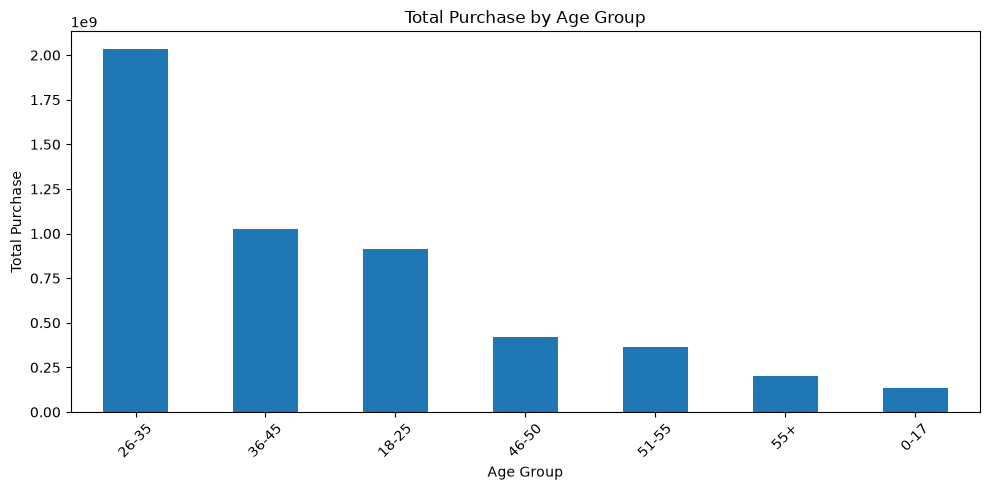

In [44]:
import matplotlib.pyplot as plt

age_purchase.plot(kind="bar", figsize=(10, 5))

plt.title("Total Purchase by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Purchase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

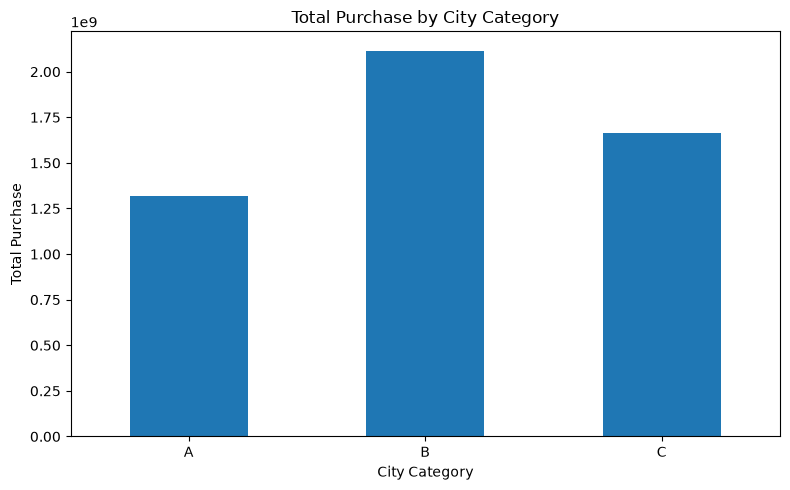

In [69]:
city_purchase = df.groupby("City_Category")["Purchase"].sum()

city_purchase.plot(kind="bar", figsize=(8, 5))

plt.title("Total Purchase by City Category")
plt.xlabel("City Category")
plt.ylabel("Total Purchase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

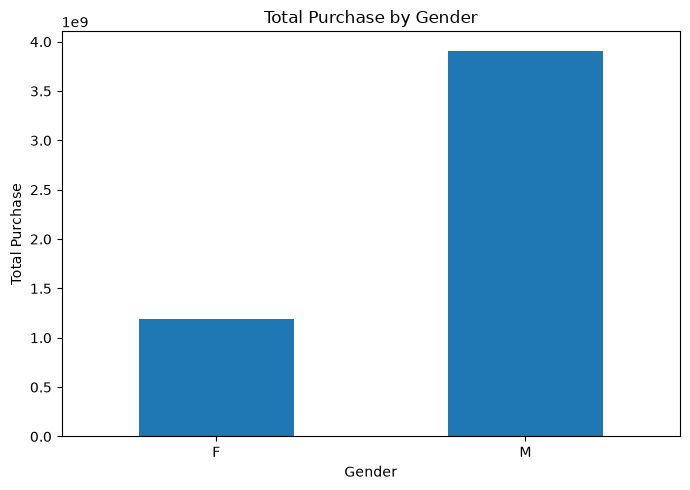

In [70]:
gender_purchase = df.groupby("Gender")["Purchase"].sum()

gender_purchase.plot(kind="bar", figsize=(7, 5))

plt.title("Total Purchase by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Purchase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

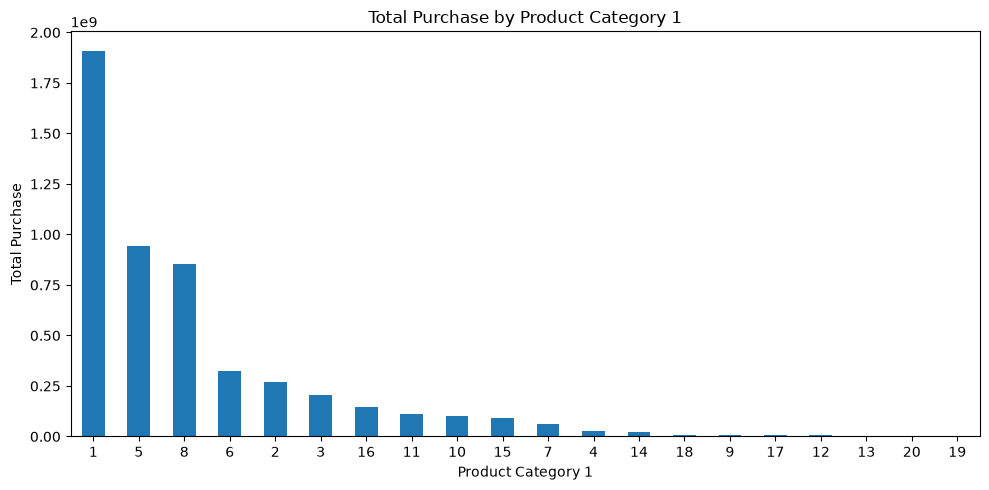

In [71]:
category1_sales = df.groupby("Product_Category_1")["Purchase"].sum().sort_values(ascending=False)

category1_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Total Purchase by Product Category 1")
plt.xlabel("Product Category 1")
plt.ylabel("Total Purchase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

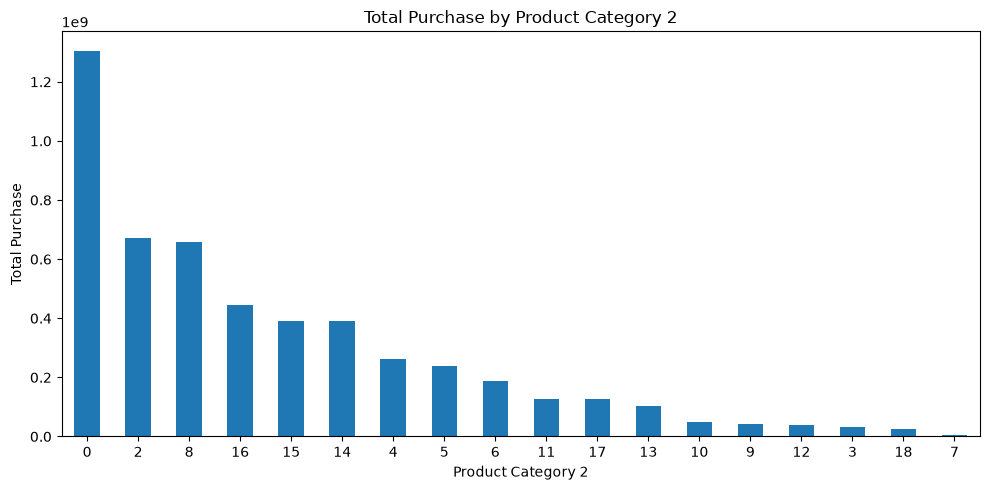

In [72]:
category2_sales = df.groupby("Product_Category_2")["Purchase"].sum().sort_values(ascending=False)

category2_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Total Purchase by Product Category 2")
plt.xlabel("Product Category 2")
plt.ylabel("Total Purchase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

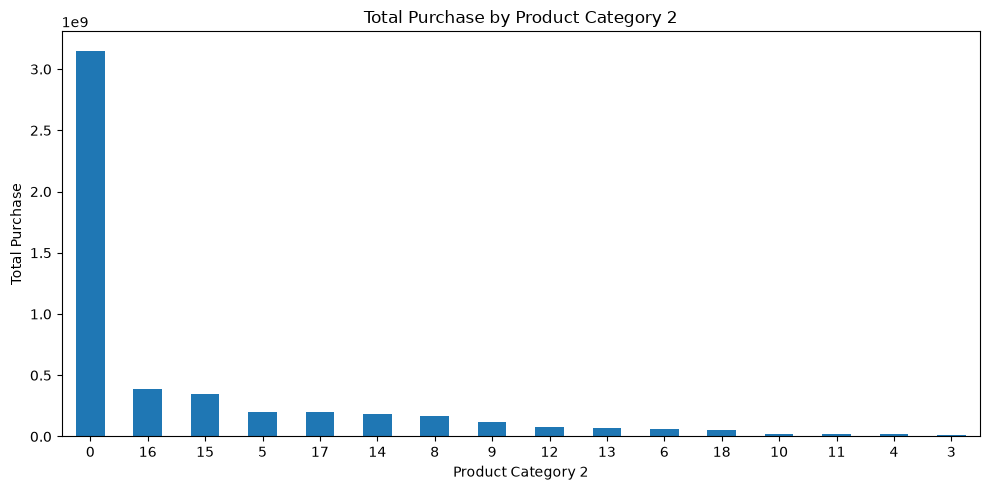

In [73]:
category2_sales = df.groupby("Product_Category_3")["Purchase"].sum().sort_values(ascending=False)

category2_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Total Purchase by Product Category 2")
plt.xlabel("Product Category 2")
plt.ylabel("Total Purchase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [74]:
gender_purchase_stats = df.groupby("Gender")["Purchase"].agg(
    ["count", "mean", "sum"]
).round(2)

gender_purchase_stats

,count,mean,sum
Gender,,,
F,135809,8734.57,1186232642
M,414259,9437.53,3909580100


In [45]:
df_final = df.copy()

print("Final dataset shape:", df_final.shape)
print("Final columns:", df_final.columns.tolist())

Final dataset shape: (550068, 12)
Final columns: ['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']


In [46]:
df_final = df.copy()

print("Final dataset shape:", df_final.shape)

Final dataset shape: (550068, 12)


<h1 style="font-size: 30px;
       font-weight: 700;">
customer lifetime value

In [47]:
customer_clv = df_final.groupby("User_ID")["Purchase"].agg(
    Total_Purchase="sum",
    Purchase_Frequency="count"
)

customer_clv["CLV"] = (
    customer_clv["Total_Purchase"] /
    customer_clv["Purchase_Frequency"]
)

customer_clv.sort_values("CLV", ascending=False).head(10)

,Total_Purchase,Purchase_Frequency,CLV
User_ID,,,
1003902,1746322,94,18577.893617
1005069,332823,18,18490.166667
1005999,330227,18,18345.944444
1001349,417743,23,18162.739130
1003461,350174,20,17508.700000
1000101,1138265,66,17246.439394
1002983,520509,31,16790.612903
1005994,705057,42,16787.071429
1000592,234872,14,16776.571429


In [55]:
customer_clv = customer_clv.reset_index()

In [56]:
customer_clv[["User_ID", "Total_Purchase", "Purchase_Frequency", "CLV"]].head(10)

,User_ID,Total_Purchase,Purchase_Frequency,CLV
0,1000001,334093,35,9545.514286
1,1000002,810472,77,10525.610390
2,1000003,341635,29,11780.517241
3,1000004,206468,14,14747.714286
4,1000005,821001,106,7745.292453
5,1000006,379930,47,8083.617021
6,1000007,234668,17,13804.000000
7,1000008,796593,77,10345.363636
8,1000009,594099,58,10243.086207
9,1000010,2169510,223,9728.744395


In [51]:
customer_clv["CLV"] = (
    customer_clv["Total_Purchase"] /
    customer_clv["Purchase_Frequency"]
)

In [52]:
customer_clv.head()

,Total_Purchase,Purchase_Frequency,CLV
User_ID,,,
1000001,334093,35,9545.514286
1000002,810472,77,10525.610390
1000003,341635,29,11780.517241
1000004,206468,14,14747.714286
1000005,821001,106,7745.292453


<h1 style="font-size: 20px;
       font-weight: 700;">
category breadth

In [19]:
category_breadth = df_final.groupby("User_ID")["Product_Category_1"].nunique()

category_breadth.describe()

count    5891.000000
mean        9.638771
std         3.595397
min         1.000000
25%         7.000000
50%         9.000000
75%        12.000000
max        19.000000
Name: Product_Category_1, dtype: float64

In [65]:
# Define product category columns
category_cols = [
    "Product_Category_1",
    "Product_Category_2",
    "Product_Category_3"
]

# Keep only columns that actually exist in df_final
category_cols = [col for col in category_cols if col in df_final.columns]

# Calculate category breadth for each customer
category_breadth = (
    df_final.groupby("User_ID")[category_cols]
    .apply(lambda x: len(set(x.values.flatten()) - {0}))
)

# Display result
category_breadth.value_counts().sort_index()

4       1
5       5
6      19
7      51
8     110
9     180
10    270
11    378
12    433
13    481
14    527
15    575
16    632
17    795
18    882
19    552
Name: count, dtype: int64

In [66]:
category_cols = [col for col in category_cols if col in df_final.columns]

In [67]:
df_final["Category_Breadth"] = df_final["User_ID"].map(category_breadth)

In [68]:
df_final[["User_ID", "Category_Breadth"]].head()

,User_ID,Category_Breadth
0,1000001,14
1,1000001,14
2,1000001,14
3,1000001,14
4,1000002,15


In [20]:
category_breadth.value_counts().sort_index()

Product_Category_1
1       3
2      15
3      78
4     196
5     430
6     561
7     628
8     610
9     588
10    528
11    477
12    396
13    374
14    315
15    265
16    221
17    140
18     49
19     17
Name: count, dtype: int64

In [21]:
city_variation = df_final.groupby("User_ID")["City_Category"].nunique()

city_variation.value_counts()

City_Category
1    5891
Name: count, dtype: int64

In [22]:
customer_clv["CLV"] = (
    customer_clv["Total_Purchase"] /
    customer_clv["Purchase_Frequency"]
)

customer_clv.sort_values("CLV", ascending=False).head(10)

,Total_Purchase,Purchase_Frequency,CLV
User_ID,,,
1003902,1746322,94,18577.893617
1005069,332823,18,18490.166667
1005999,330227,18,18345.944444
1001349,417743,23,18162.739130
1003461,350174,20,17508.700000
1000101,1138265,66,17246.439394
1002983,520509,31,16790.612903
1005994,705057,42,16787.071429
1000592,234872,14,16776.571429


<h1 style="font-size: 20px;
       font-weight: 700;">
city loyalty index

In [23]:
city_loyalty = df_final.groupby(
    ["User_ID", "City_Category", "Stay_In_Current_City_Years"]
)["Purchase"].mean().reset_index()

city_loyalty["Stay_Years_Num"] = (
    city_loyalty["Stay_In_Current_City_Years"]
    .replace({"4+": "4"})
    .astype(float)
)

city_loyalty["City_Loyalty_Index"] = (
    city_loyalty["Purchase"] * city_loyalty["Stay_Years_Num"]
)

city_loyalty.sort_values(
    "City_Loyalty_Index", ascending=False
).head(10)

,User_ID,City_Category,Stay_In_Current_City_Years,Purchase,Stay_Years_Num,City_Loyalty_Index
5200,1005336,C,4+,16490.466667,4.0,65961.866667
5536,1005679,C,4+,16254.561224,4.0,65018.244898
4031,1004136,C,4+,15310.727273,4.0,61242.909091
837,1000863,C,4+,15099.789474,4.0,60399.157895
4966,1005094,C,4+,14954.272727,4.0,59817.090909
1264,1001305,B,4+,14766.812500,4.0,59067.250000
2816,1002894,B,4+,14751.867647,4.0,59007.470588
2739,1002816,C,4+,14669.666667,4.0,58678.666667
1446,1001490,B,4+,14312.500000,4.0,57250.000000
1372,1001414,C,4+,14268.230769,4.0,57072.923077


In [24]:
print("CLV created:", "CLV" in customer_clv.columns)
print("Category Breadth created:", category_breadth is not None)
print("City Loyalty Index created:", "City_Loyalty_Index" in city_loyalty.columns)

CLV created: True
Category Breadth created: True
City Loyalty Index created: True


<h1 style="font-size: 32px;
       font-weight: 700;"> STATISTIC ANALYSIS IN PYTHON

In [61]:
# Check the actual column name
print(df_final.columns.tolist())

['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']


In [62]:
# Convert Stay_In_Current_City_Years into numeric values
df_final["Stay_Years_Num"] = df_final["Stay_In_Current_City_Years"].replace({
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4+": 4
}).astype(int)

In [63]:
import statsmodels.api as sm

X = df_final[["Occupation", "Stay_Years_Num"]]
X = sm.add_constant(X)

y = df_final["Purchase"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Purchase   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     125.8
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.50e-55
Time:                        22:17:03   Log-Likelihood:            -5.4680e+06
No. Observations:              550068   AIC:                         1.094e+07
Df Residuals:                  550065   BIC:                         1.094e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           9100.5286     14.374    633.

In [26]:
from scipy.stats import ttest_ind

male_purchase = df_final[df_final["Gender"] == "M"]["Purchase"]
female_purchase = df_final[df_final["Gender"] == "F"]["Purchase"]

t_stat, p_value = ttest_ind(
    male_purchase,
    female_purchase,
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

T-statistic: 46.3582
P-value: 0.0


In [27]:
from scipy.stats import f_oneway

age_groups = [
    group["Purchase"].values
    for _, group in df_final.groupby("Age")
]

f_stat, p_value = f_oneway(*age_groups)

print("F-statistic:", round(f_stat, 4))
print("P-value:", p_value)

F-statistic: 40.5758
P-value: 1.0535639391157083e-49


In [28]:
numeric_cols = [
    "Occupation",
    "Marital_Status",
    "Product_Category_1",
    "Product_Category_2",
    "Product_Category_3",
    "Purchase"
]

correlation_matrix = df_final[numeric_cols].corr()

correlation_matrix["Purchase"].sort_values(ascending=False)

Purchase              1.000000
Product_Category_3    0.288501
Product_Category_2    0.052288
Occupation            0.020833
Marital_Status       -0.000463
Product_Category_1   -0.343703
Name: Purchase, dtype: float64

<h1 style="font-size: 32px;
       font-weight: 600;"> Heatmaps to study correlations between demographics and purchase
amounts.

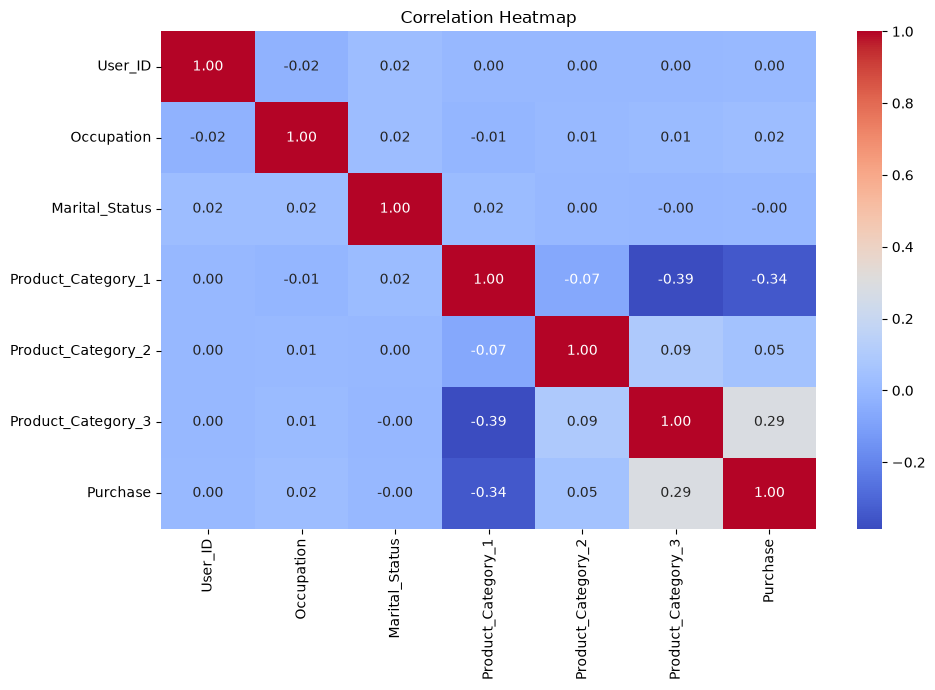

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df_final.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import t

mean_purchase = df_final["Purchase"].mean()
std_purchase = df_final["Purchase"].std()
n = len(df_final)

confidence = 0.95
standard_error = std_purchase / (n ** 0.5)

margin_error = t.ppf(
    (1 + confidence) / 2,
    df=n - 1
) * standard_error

lower_ci = mean_purchase - margin_error
upper_ci = mean_purchase + margin_error

print("Mean Purchase:", round(mean_purchase, 2))
print("95% Confidence Interval:")
print("Lower:", round(lower_ci, 2))
print("Upper:", round(upper_ci, 2))

Mean Purchase: 9263.97
95% Confidence Interval:
Lower: 9250.69
Upper: 9277.24


In [31]:
print("Statistical Analysis Completed")
print("- T-test: Male vs Female Purchase")
print("- ANOVA: Purchase across Age Groups")
print("- Correlation: Numerical Variables vs Purchase")
print("- 95% Confidence Interval: Overall Mean Purchase")

Statistical Analysis Completed
- T-test: Male vs Female Purchase
- ANOVA: Purchase across Age Groups
- Correlation: Numerical Variables vs Purchase
- 95% Confidence Interval: Overall Mean Purchase


<h1 style="font-size: 32px;
       font-weight: 500;"> 
statistics analysis completed

In [32]:
statistical_summary = pd.DataFrame({
    "Test": [
        "T-test",
        "ANOVA",
        "Correlation Analysis",
        "95% Confidence Interval"
    ],
    "Purpose": [
        "Compare Purchase between Male and Female customers",
        "Compare Purchase across Age Groups",
        "Measure relationships among numerical variables",
        "Estimate the population mean Purchase"
    ]
})

statistical_summary

,Test,Purpose
0,T-test,Compare Purchase between Male and Female custo...
1,ANOVA,Compare Purchase across Age Groups
2,Correlation Analysis,Measure relationships among numerical variables
3,95% Confidence Interval,Estimate the population mean Purchase


In [33]:
derived_features_summary = pd.DataFrame({
    "Feature": [
        "CLV",
        "Category Breadth",
        "City Loyalty Index"
    ],
    "Definition": [
        "Total Purchase per User / Number of Transactions",
        "Number of unique Product Category 1 values purchased by a customer",
        "Average Purchase × Stay in Current City Years"
    ]
})

derived_features_summary

,Feature,Definition
0,CLV,Total Purchase per User / Number of Transactions
1,Category Breadth,Number of unique Product Category 1 values pur...
2,City Loyalty Index,Average Purchase × Stay in Current City Years


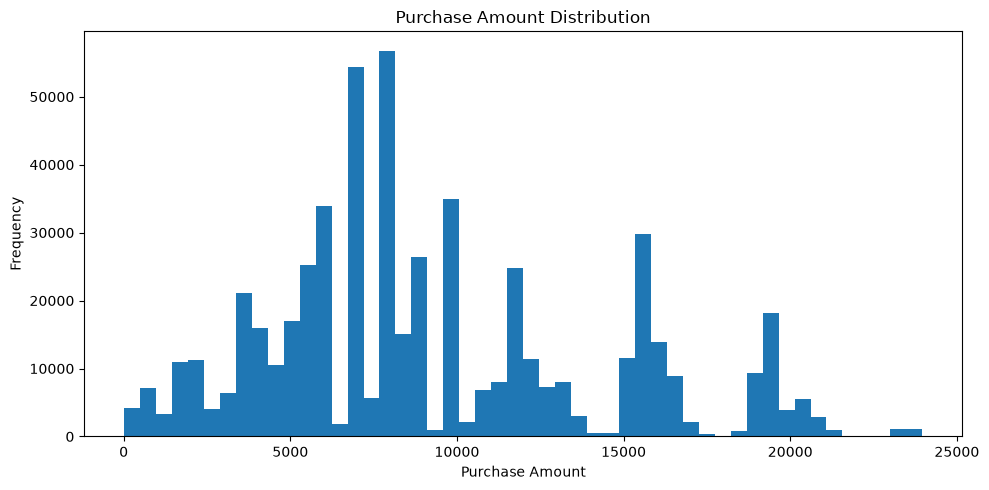

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df_final["Purchase"], bins=50)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

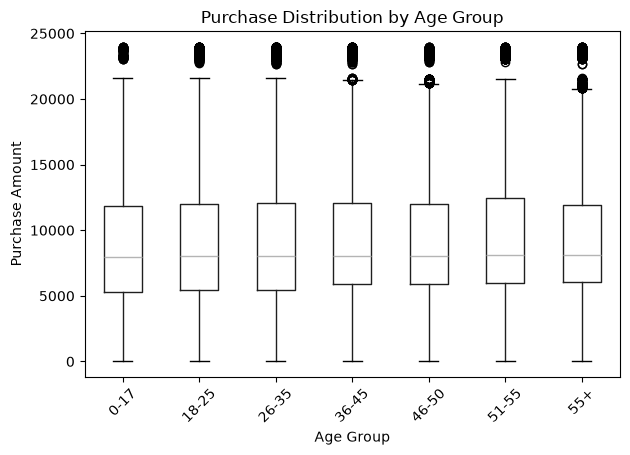

In [35]:
plt.figure(figsize=(10, 6))

df_final.boxplot(
    column="Purchase",
    by="Age",
    grid=False
)

plt.title("Purchase Distribution by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

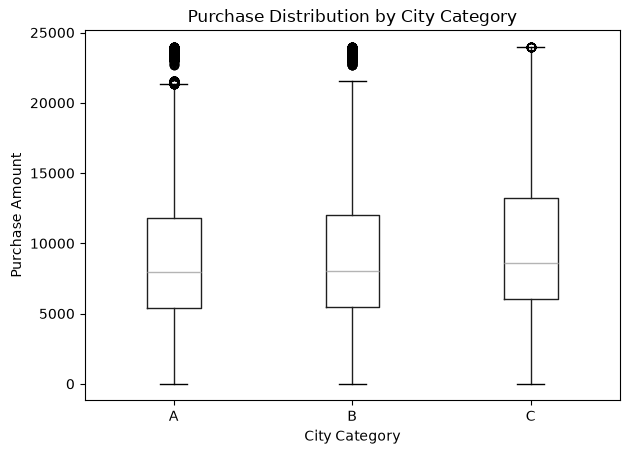

In [36]:
plt.figure(figsize=(8, 6))

df_final.boxplot(
    column="Purchase",
    by="City_Category",
    grid=False
)

plt.title("Purchase Distribution by City Category")
plt.suptitle("")
plt.xlabel("City Category")
plt.ylabel("Purchase Amount")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

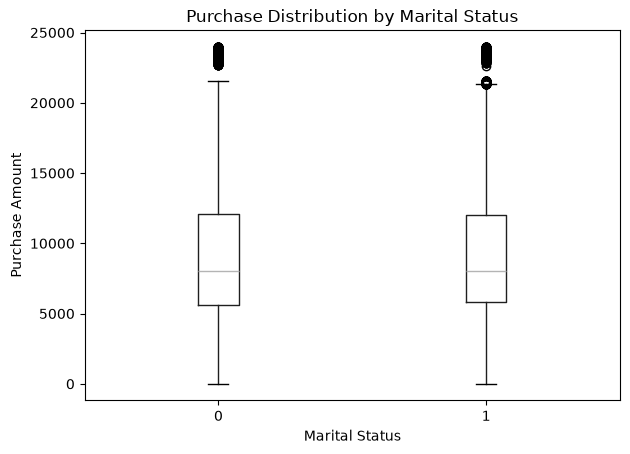

In [37]:
plt.figure(figsize=(8, 6))

df_final.boxplot(
    column="Purchase",
    by="Marital_Status",
    grid=False
)

plt.title("Purchase Distribution by Marital Status")
plt.suptitle("")
plt.xlabel("Marital Status")
plt.ylabel("Purchase Amount")

plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import f_oneway

city_groups = [
    group["Purchase"].values
    for _, group in df_final.groupby("City_Category")
]

f_stat_city, p_value_city = f_oneway(*city_groups)

print("City Category ANOVA")
print("F-statistic:", round(f_stat_city, 4))
print("P-value:", p_value_city)

City Category ANOVA
F-statistic: 1130.746
P-value: 0.0


In [39]:
t_stat, p_value = ttest_ind(
    male_purchase,
    female_purchase,
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

T-statistic: 46.3582
P-value: 0.0


In [40]:
f_stat, p_value = f_oneway(*age_groups)

print("F-statistic:", round(f_stat, 4))
print("P-value:", p_value)

F-statistic: 40.5758
P-value: 1.0535639391157083e-49


In [41]:
f_stat_city, p_value_city = f_oneway(*city_groups)

print("City Category ANOVA")
print("F-statistic:", round(f_stat_city, 4))
print("P-value:", p_value_city)

City Category ANOVA
F-statistic: 1130.746
P-value: 0.0


In [42]:
correlation_matrix["Purchase"].sort_values(ascending=False)

Purchase              1.000000
Product_Category_3    0.288501
Product_Category_2    0.052288
Occupation            0.020833
Marital_Status       -0.000463
Product_Category_1   -0.343703
Name: Purchase, dtype: float64

In [43]:
print("Mean Purchase:", round(mean_purchase, 2))
print("95% Confidence Interval:")
print("Lower:", round(lower_ci, 2))
print("Upper:", round(upper_ci, 2))

Mean Purchase: 9263.97
95% Confidence Interval:
Lower: 9250.69
Upper: 9277.24


## Statistical Analysis – Assumptions and Limitations (actual calculation)

### Assumptions

1. **Independence of observations:** Each transaction is treated as an individual observation for the statistical tests.

2. **T-test:** Welch's independent two-sample t-test was used to compare purchase amounts between male and female customers, without assuming equal variances.

3. **ANOVA:** One-way ANOVA was used to compare purchase amounts across age groups and city categories. The analysis assumes independence, approximately normal distributions within groups, and reasonably similar variances across groups.

4. **Correlation analysis:** Pearson correlation was used to examine linear relationships between numerical variables and Purchase.

5. **Significance level:** A significance level of 5% (α = 0.05) was considered for hypothesis testing.

### Limitations

1. The dataset contains transaction-level purchase records from the Black Friday campaign and does not provide a long-term customer observation period.

2. Product categories are masked numerical identifiers, so specific product-category names cannot be interpreted.

3. Product_Category_2 and Product_Category_3 contain zero values representing unavailable/unknown category information after data cleaning.

4. Statistical significance does not necessarily imply a strong or practically important business relationship.

5. The analysis identifies associations and differences in the available data but does not establish causal relationships.

6. The dataset does not contain explicit promotional, discount, profit, or campaign-response variables; therefore, promotional effectiveness can only be assessed through available proxy metrics.

In [45]:
print("===== PYTHON PROJECT COMPLETION CHECK =====")

print("Dataset:", df_final.shape)
print("CLV:", "CLV" in customer_clv.columns)
print("Category Breadth:", category_breadth is not None)
print("City Loyalty Index:", "City_Loyalty_Index" in city_loyalty.columns)

print("T-test completed:", "t_stat" in globals() and "p_value" in globals())
print("Age ANOVA completed:", "f_stat" in globals())
print("City ANOVA completed:", "f_stat_city" in globals())
print("Correlation analysis:", "correlation_matrix" in globals())
print("95% Confidence Interval:", "lower_ci" in globals() and "upper_ci" in globals())

print("============================================")

===== PYTHON PROJECT COMPLETION CHECK =====
Dataset: (550068, 12)
CLV: True
Category Breadth: True
City Loyalty Index: True
T-test completed: True
Age ANOVA completed: True
City ANOVA completed: True
Correlation analysis: True
95% Confidence Interval: True


## Statistical Analysis — Assumptions and Limitations(Documentation/Summary)

### Assumptions
- The observations are treated as independent transactions for the statistical tests.
- The t-test compares purchase values between the gender groups.
- ANOVA assumes independence of observations, approximately normal residuals, and reasonably similar variances across groups.
- Correlation analysis measures linear relationships between the selected numerical variables and Purchase.
- A significance level of 5% (α = 0.05) is used for hypothesis testing.

### Limitations
- The dataset contains masked occupation and product category codes, so the business meaning of individual categories cannot be identified.
- Product_Category_2 and Product_Category_3 contain zero values representing unavailable/unknown categories after data cleaning.
- The dataset represents Black Friday transactions and may not generalize to normal-day purchasing behavior.
- Statistical significance does not necessarily imply a strong or practically important business relationship.
- The City Loyalty Index and CLV are analytical metrics derived from the available dataset and should be interpreted within this project context.